# The AI Race: Data Analysis & Chart Prototyping

**Source:** [LifeArchitect.ai Models Table](https://lifearchitect.ai/models-table), April 2026  
**Raw data:** `2026 LifeArchitect.ai data (shared) - NEW - Models Table.csv`  
**Processed to:** `models_data.json` (via `process_data.py`)  
**MMLU subset:** `mmlu_data.json` (258 real + 2 estimated entries for Alibaba's newest models which has params but no MMLU values yet)

Trying to understand how the AI model race has evolved — who's building what, how fast, and whether the "open vs closed" divide is really as clear-cut as it seems. The news peg is Alibaba's sudden pivot to closed-source models in April 2026 ([Bloomberg](https://www.bloomberg.com/news/articles/2026-04-02/alibaba-unveils-third-closed-source-ai-model-in-focus-on-profit)), and OpenAI's move in the opposite direction last year.

### The assignment: 
"We hate infodumps: for this exercise, you will take a piece that exists as an infodump-y interactive or visualization and remix it into a narrative story. Think about how you can break the data up into different slices or anecdotes to turn it into a more manageable experience."

This dataset has been visualised here - [Information Is Beautiful](https://informationisbeautiful.net/visualizations/the-rise-of-generative-ai-large-language-models-llms-like-chatgpt/) - before, and my goal here is to remix it to turn it into a narrative that's less of an infodump.

### Key data limitation:
Only 258 of 796 models (32%) have published MMLU scores. These tend to be the bigger, newer, more competitive models — so the MMLU chart shows the "benchmarked elite" (which is branded by the chart's orginal makers as "Major LLMs" -- I adopted it.), not the full picture. Models without MMLU are mostly pre-2024 or sub-1B. See Section 10 for full breakdown.

In [96]:
# ── Load and prep ──
# The JSON was processed from the raw CSV by process_data.py, which:
# - Extracted model name, lab, params, tokens, date, arch, reasoning, SOTA tags
# - Classified labs into groups (Google, OpenAI, Meta, etc.)
# - Added open_weight field based on whether the playground URL points to HuggingFace
#   (a proxy for downloadable weights — not perfect, but verifiable)
# - Added MMLU scores where available

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import defaultdict
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'sans-serif'],
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.dpi': 150,
})

with open('data/models_data.json') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# Chinese lab identification — keyword match on the original lab name field.
# Not perfect (misses some smaller labs) but catches the major players.
CHINA_KW = [
    'Alibaba', 'Qwen', 'DeepSeek', 'Baidu', 'ERNIE', 'Tencent', 'Hunyuan',
    'Xiaomi', 'MiMo', 'Moonshot', 'Kimi', 'MiniMax', 'Zhipu', 'Z.AI', 'GLM',
    'ByteDance', '01.AI', 'Yi-', 'SenseTime', 'Shanghai AI', 'Inclusion',
    'InclusionAI', 'Nanbeige', 'JD Open', 'StepFun', 'Internlm', 'YuanLab',
    'Baichuan', 'RWKV', 'MOSS', 'vivo', 'Fudan'
]
df['is_chinese'] = df['lab'].apply(lambda x: any(kw in x for kw in CHINA_KW))

print(f'{len(df)} models, {df.date.min().date()} to {df.date.max().date()}')
df.head(10)

796 models, 2017-06-01 to 2026-04-01


,model,lab,lab_group,params,tokens,alscore,date,public,arch,reasoning,sota,moe,tags,open_weight,mmlu,year,is_chinese
0,Transformer (big),Google,Google,0.213,9.80,0.0,2017-06-01,🟢,Dense,False,True,False,SOTA,False,NaN,2017,False
1,Transformer (base),Google,Google,0.065,3.30,0.0,2017-06-01,🟢,Dense,False,True,False,SOTA,False,NaN,2017,False
2,ULMFiT,Fast.ai,Fast.ai,0.034,1.44,0.0,2018-01-01,🟢,Dense,False,False,False,,False,NaN,2018,False
3,GPT-1,OpenAI,OpenAI,0.117,98.40,0.0,2018-06-01,🟢,Dense,False,True,False,SOTA,True,NaN,2018,False
4,BERT,Google,Google,0.340,137.00,0.0,2018-10-01,🟢,Dense,False,True,False,SOTA,True,NaN,2018,False
5,GPT-2,OpenAI,OpenAI,1.500,40.00,0.0,2019-02-01,🟢,Dense,False,True,False,SOTA,True,32.4,2019,False
6,RoBERTa,Meta AI,Meta,0.355,2200.00,0.1,2019-07-01,🟢,Dense,False,False,False,,True,27.9,2019,False
7,Megatron-LM,NVIDIA,NVIDIA,8.300,800.00,0.3,2019-09-01,🟢,Dense,False,False,False,,False,NaN,2019,False
8,T5,Google,Google,11.000,1000.00,0.3,2019-10-01,🟢,Dense,False,False,False,,True,NaN,2019,False
9,Meena,Google,Google,2.600,10000.00,0.5,2020-01-01,🔴,Dense,False,True,False,SOTA,False,NaN,2020,False


---
## 1. How fast did this happen?

First question: how many models are we talking about, and when did the flood start?

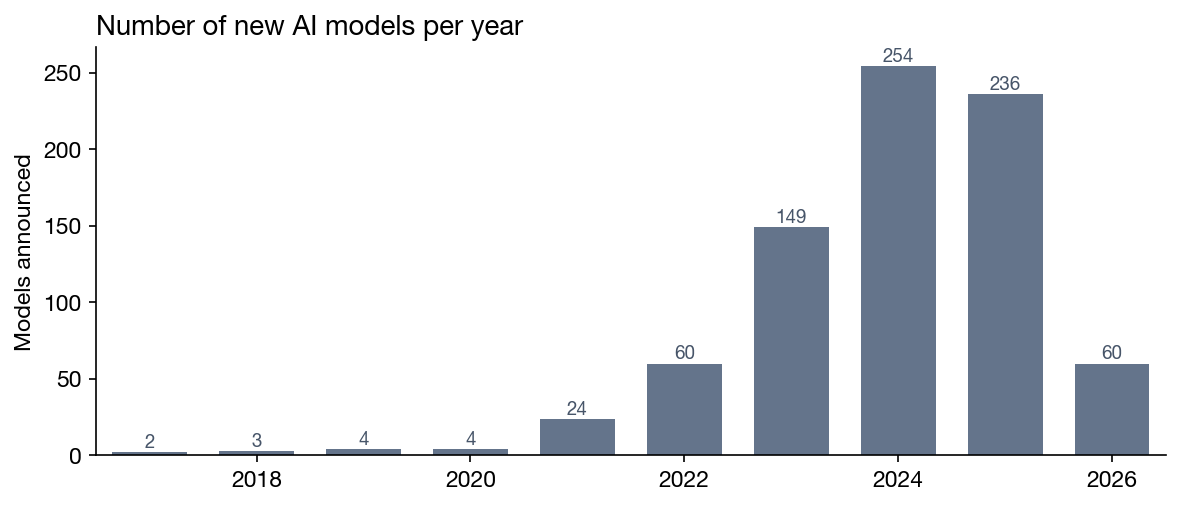

In [97]:
# The growth curve is wild: 2 models in 2017, then 254 in 2024.
# 2026 is partial-year data (through April) so it'll look low — don't read into it.

counts = df.groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(counts.index, counts.values, color='#64748b', width=0.7)
ax.set_ylabel('Models announced')
ax.set_title('Number of new AI models per year', fontweight='bold', loc='left')
for i, v in enumerate(counts.values):
    ax.text(counts.index[i], v + 3, str(v), ha='center', fontsize=9, color='#475569')
ax.set_xlim(2016.5, 2026.5)
plt.tight_layout()
plt.show()

# Takeaway: the inflection was 2023 (ChatGPT effect) and 2024 was the peak.
# 2025 is roughly on pace to match 2024.

---
## 2. Who's building them?

Google leads by sheer volume, but volume ≠ impact. Let's see the top 15.

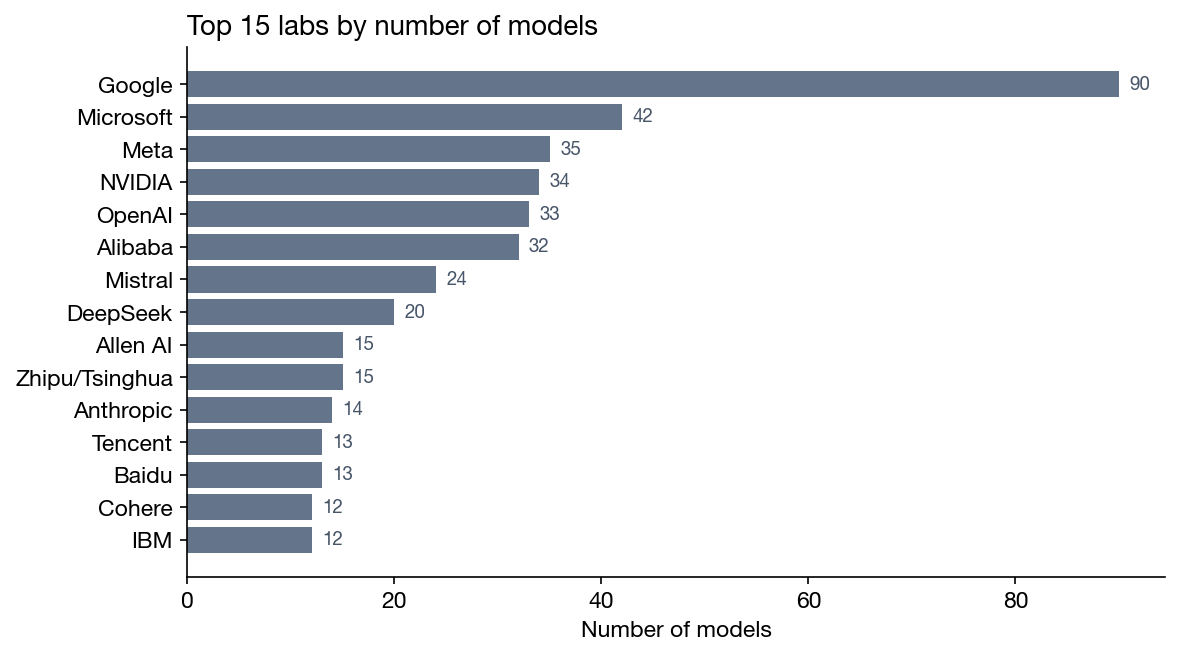

In [98]:
# Google at 90 models is misleading — many are small research projects (FunctionGemma, etc.)
# The more interesting question is: who gets results? That's next.

top_labs = df['lab_group'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(top_labs.index[::-1], top_labs.values[::-1], color='#64748b')
ax.set_xlabel('Number of models')
ax.set_title('Top 15 labs by number of models', fontweight='bold', loc='left')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9, color='#475569')
plt.tight_layout()
plt.show()

---
## 3. Who actually sets records?

Volume doesn't tell us who's leading. SOTA rate does — what percentage of a lab's models set new state-of-the-art benchmarks when released? This separates the frontier racers from the research tinkerers.

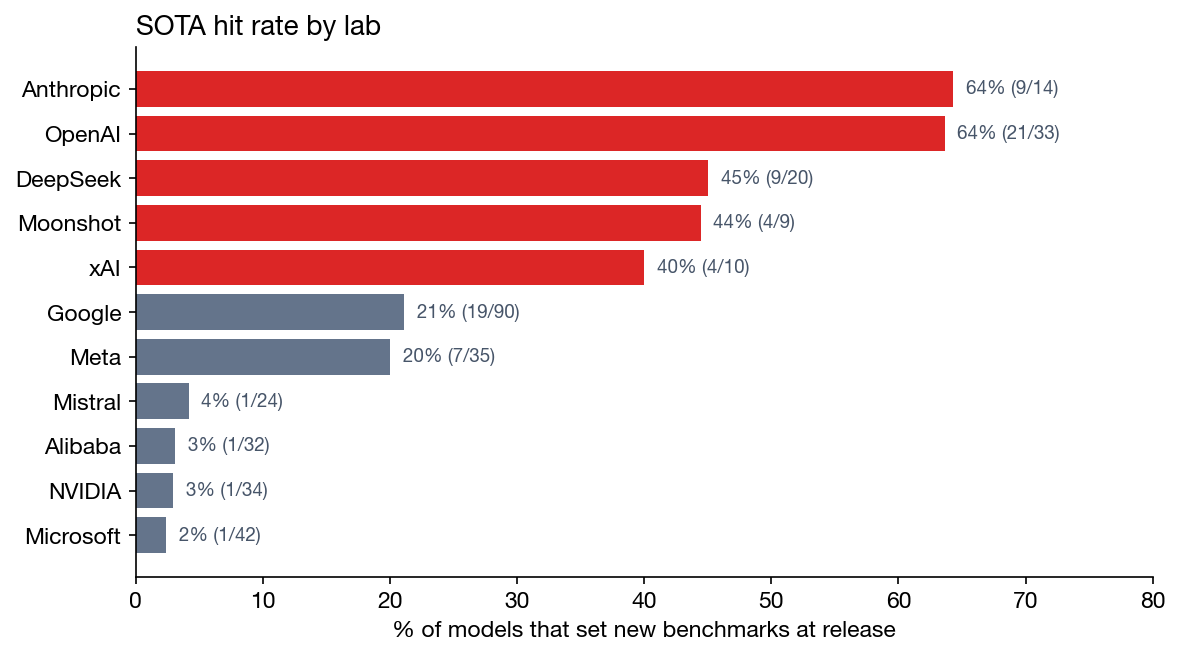

In [99]:
# The surprise here is DeepSeek and Moonshot — tiny teams, very few models,
# but nearly half of everything they release sets a new record.
# Microsoft at 2% makes sense: they're building Phi (small/efficient), not frontier models.

labs_of_interest = ['OpenAI', 'Anthropic', 'Google', 'Meta', 'DeepSeek',
                    'Alibaba', 'xAI', 'Moonshot', 'Mistral', 'NVIDIA', 'Microsoft']
sota_data = []
for lab in labs_of_interest:
    subset = df[df['lab_group'] == lab]
    total = len(subset)
    sota = subset['sota'].sum()
    sota_data.append({'lab': lab, 'total': total, 'sota': sota,
                      'rate': sota / total * 100 if total else 0})
sota_df = pd.DataFrame(sota_data).sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#dc2626' if r >= 40 else '#64748b' for r in sota_df['rate']]
bars = ax.barh(sota_df['lab'], sota_df['rate'], color=colors)
ax.set_xlabel('% of models that set new benchmarks at release')
ax.set_title('SOTA hit rate by lab', fontweight='bold', loc='left')
for bar, row in zip(bars, sota_df.itertuples()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{row.rate:.0f}% ({row.sota}/{row.total})',
            va='center', fontsize=9, color='#475569')
ax.set_xlim(0, 80)
plt.tight_layout()
plt.show()

# Key stat for the story: DeepSeek 45% with just 20 models. Moonshot 44% with 9.

---
## 4. The architecture switch nobody talks about

Before we get to open vs closed, there's a hidden "switching sides" story in the data: the shift from Dense to Mixture of Experts (MoE). Early models activated every parameter for every input. MoE activates only a fraction — letting models scale to trillions of parameters without proportional compute costs. This is a measurable, binary switch and some companies did it overnight.

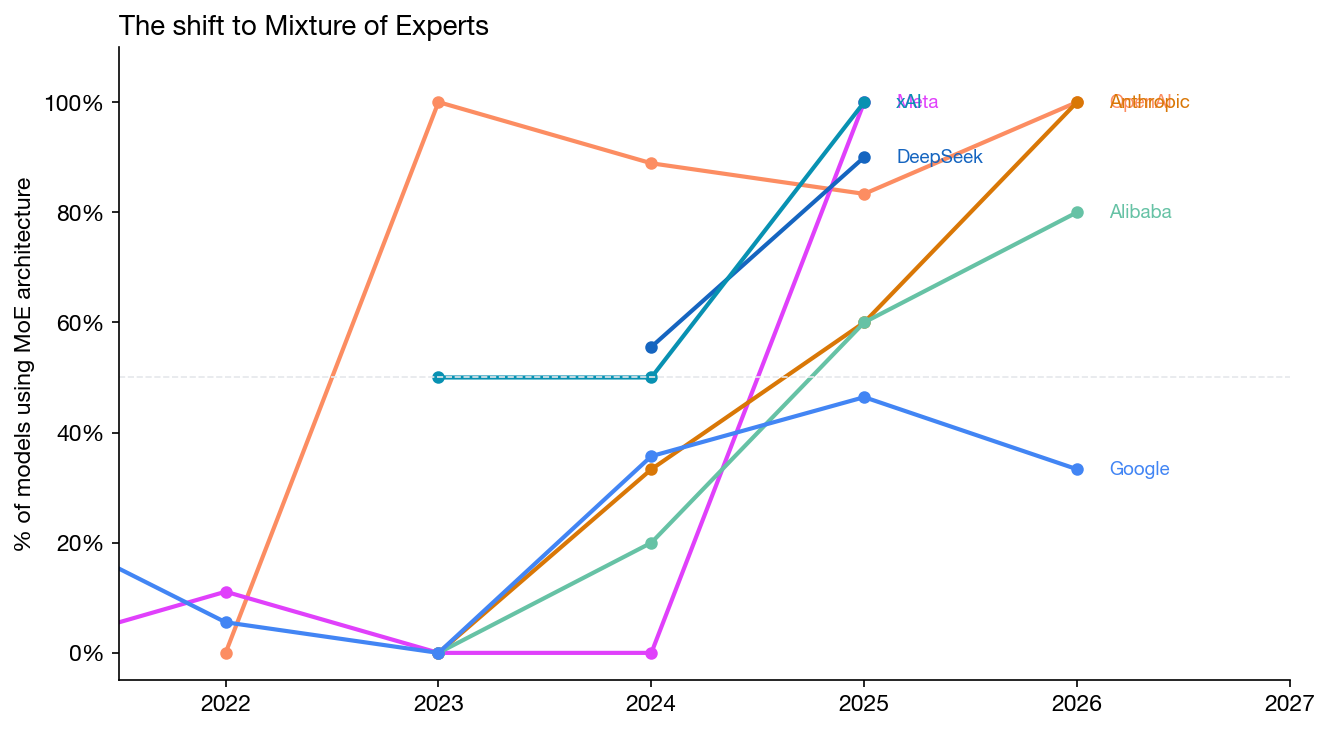


% MoE by lab by year:
OpenAI       2018:0%  2019:0%  2020:0%  2021:0%  2022:0%  2023:100%  2024:89%  2025:83%  2026:100%
Meta         2019:0%  2020:0%  2021:0%  2022:11%  2023:0%  2024:0%  2025:100%
Anthropic    2021:0%  2022:0%  2023:0%  2024:33%  2025:60%  2026:100%
Alibaba      2023:0%  2024:20%  2025:60%  2026:80%
DeepSeek     2024:56%  2025:90%  2026:100%
Google       2017:0%  2018:0%  2019:0%  2020:0%  2021:25%  2022:6%  2023:0%  2024:36%  2025:46%  2026:33%
xAI          2023:50%  2024:50%  2025:100%  2026:100%


In [100]:
# Look at this: OpenAI went from 0% MoE to 100% in a SINGLE YEAR (2022→2023).
# Meta did the same thing two years later (2024→2025).

arch_labs = ['OpenAI', 'Meta', 'Anthropic', 'Alibaba', 'DeepSeek', 'Google', 'xAI']
arch_colors = {
    'OpenAI': '#fc8d62', 'Meta': '#e040fb', 'Anthropic': '#d97706',
    'Alibaba': '#66c2a5', 'DeepSeek': '#1565c0', 'Google': '#4285f4', 'xAI': '#0891b2'
}

fig, ax = plt.subplots(figsize=(9, 5))
for lab in arch_labs:
    subset = df[df['lab_group'] == lab]
    by_year = subset.groupby('year')['moe'].agg(['sum', 'count'])
    by_year['pct'] = by_year['sum'] / by_year['count'] * 100
    by_year = by_year[by_year['count'] >= 2]  # need at least 2 models to be meaningful
    if len(by_year) >= 2:
        ax.plot(by_year.index, by_year['pct'], 'o-', label=lab,
                color=arch_colors[lab], linewidth=2, markersize=5)
        ax.text(by_year.index[-1] + 0.15, by_year['pct'].iloc[-1], lab,
                fontsize=9, color=arch_colors[lab], fontweight='bold', va='center')

ax.set_ylabel('% of models using MoE architecture')
ax.set_title('The shift to Mixture of Experts', fontweight='bold', loc='left')
ax.set_ylim(-5, 110)
ax.set_xlim(2021.5, 2027)
ax.axhline(50, color='#e5e7eb', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

# Print the raw numbers so we can cite them precisely
print('\n% MoE by lab by year:')
for lab in arch_labs:
    subset = df[df['lab_group'] == lab]
    by_year = subset.groupby('year')['moe'].agg(['sum', 'count'])
    by_year['pct'] = by_year['sum'] / by_year['count'] * 100
    years_str = '  '.join(f'{yr}:{row.pct:.0f}%' for yr, row in by_year.iterrows())
    print(f'{lab:12s} {years_str}')

**Finding:** OpenAI flipped from 0% to 100% MoE in 2022→2023. Meta did the same in 2024→2025.

---
## 5. The reasoning divide

This is the newest fault line. "Reasoning" models explicitly think step-by-step before answering — they can solve maths competitions and write production code. The question: who adopted it and who didn't?

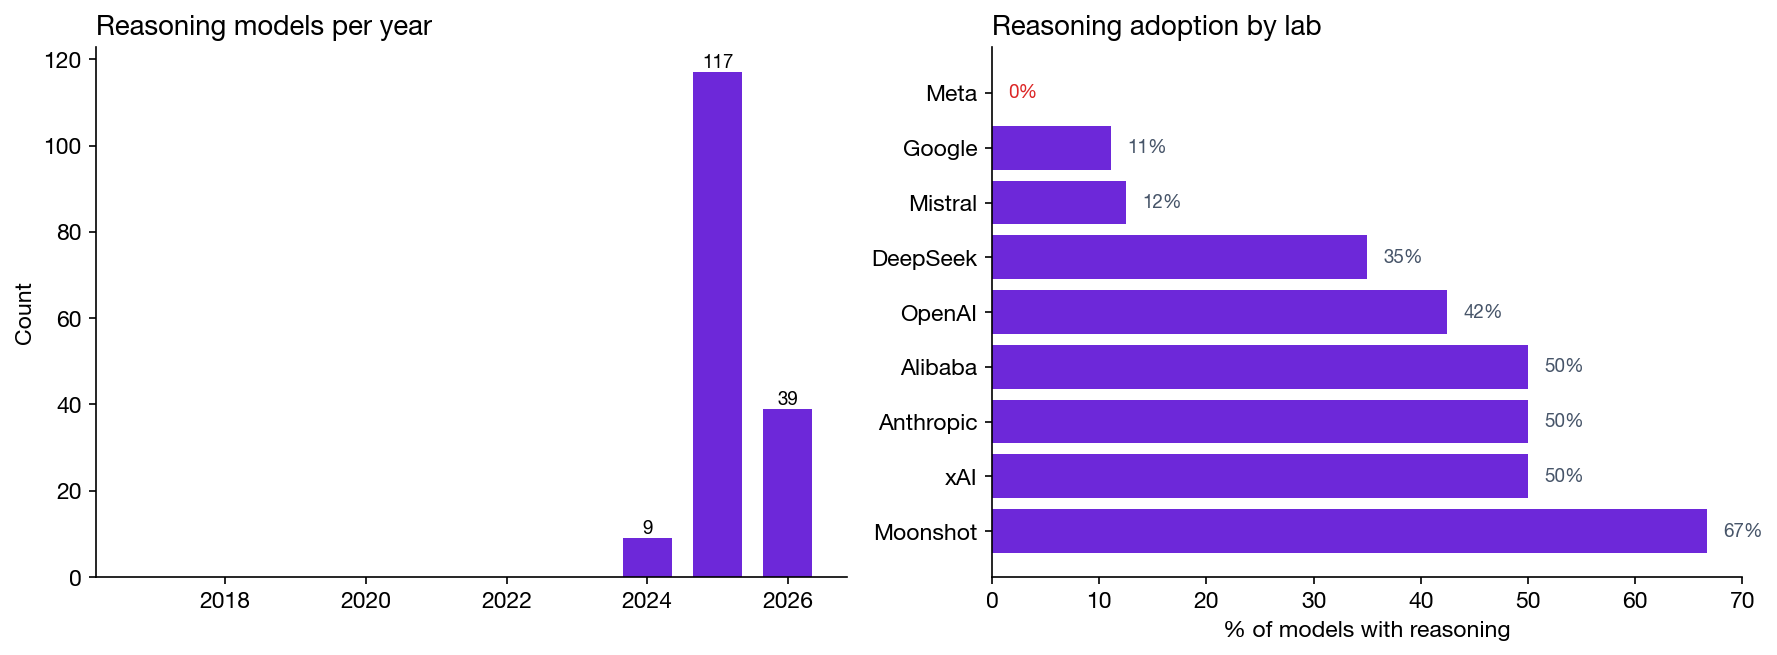

In [101]:
# Left chart: the reasoning explosion happened in 2025. Before that, barely anyone was doing it.
# Right chart: Meta at 0% is the outlier. 35 models, not a single reasoning model.
#   Their Llama 4 Behemoth is expected to have reasoning, but it's still in preview.
#   Meanwhile Moonshot (67%) is a tiny Chinese startup punching way above its weight.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: count per year
rby = df.groupby('year')['reasoning'].sum()
axes[0].bar(rby.index, rby.values, color='#6d28d9', width=0.7)
axes[0].set_title('Reasoning models per year', fontweight='bold', loc='left')
axes[0].set_ylabel('Count')
for yr, val in zip(rby.index, rby.values):
    if val > 0:
        axes[0].text(yr, val + 1, str(int(val)), ha='center', fontsize=9)

# Right: % by lab
reason_labs = ['Moonshot', 'xAI', 'Anthropic', 'Alibaba', 'OpenAI',
               'DeepSeek', 'Mistral', 'Google', 'Meta']
reason_pcts = [df[df['lab_group']==l]['reasoning'].mean()*100 for l in reason_labs]
colors = ['#6d28d9' if p > 0 else '#dc2626' for p in reason_pcts]
axes[1].barh(reason_labs, reason_pcts, color=colors)
axes[1].set_xlabel('% of models with reasoning')
axes[1].set_title('Reasoning adoption by lab', fontweight='bold', loc='left')
for i, (lab, pct) in enumerate(zip(reason_labs, reason_pcts)):
    label = f'{pct:.0f}%' if pct > 0 else '0%'
    axes[1].text(max(pct, 0) + 1.5, i, label, va='center', fontsize=9,
                 color='#dc2626' if pct == 0 else '#475569')

plt.tight_layout()
plt.show()

**Finding:** Meta: 35 models, zero reasoning. Moonshot: 67% reasoning with just 9 models.

---
## 6. China's rise — from zero to 30%

In 2020, not a single model came from a Chinese lab. By 2025, nearly one in three did. The acceleration after DeepSeek R1 (January 2025) is visible.

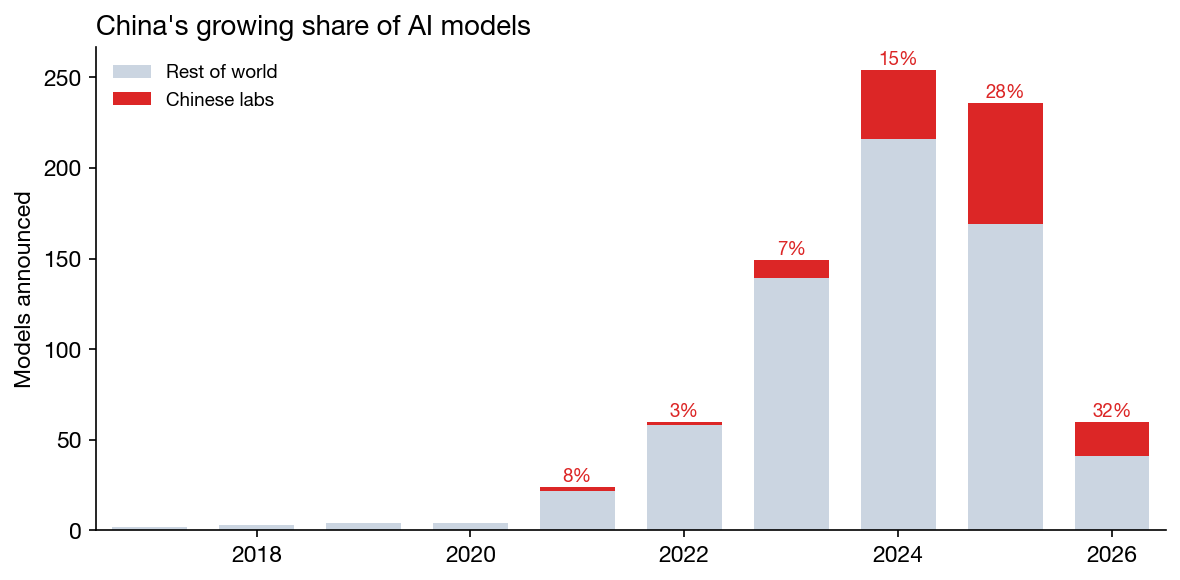

      chinese  total        pct
year                           
2017        0      2   0.000000
2018        0      3   0.000000
2019        0      4   0.000000
2020        0      4   0.000000
2021        2     24   8.333333
2022        2     60   3.333333
2023       10    149   6.711409
2024       38    254  14.960630
2025       67    236  28.389831
2026       19     60  31.666667


In [102]:
# The red portion of each bar is Chinese labs. The % labels show their share.
# Note: our Chinese lab identification is keyword-based — we might miss some smaller labs,
# so these numbers are likely a floor, not a ceiling.

cby = df.groupby('year').agg(total=('model','count'), chinese=('is_chinese','sum'))
cby['pct'] = cby['chinese'] / cby['total'] * 100
cby['non_chinese'] = cby['total'] - cby['chinese']

fig, ax = plt.subplots(figsize=(8, 4))
years = cby.index
ax.bar(years, cby['non_chinese'], color='#cbd5e1', width=0.7, label='Rest of world')
ax.bar(years, cby['chinese'], bottom=cby['non_chinese'],
       color='#dc2626', width=0.7, label='Chinese labs')
for yr, row in cby.iterrows():
    if row['pct'] > 0:
        ax.text(yr, row['total'] + 3, f"{row['pct']:.0f}%",
                ha='center', fontsize=9, color='#dc2626', fontweight='bold')
ax.set_title("China's growing share of AI models", fontweight='bold', loc='left')
ax.set_ylabel('Models announced')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.set_xlim(2016.5, 2026.5)
plt.tight_layout()
plt.show()

print(cby[['chinese', 'total', 'pct']].to_string())

---
## 7. The DeepSeek R1 effect on Chinese reasoning

How big of a stampede did DeepSeek R1 (January 2025) trigger?

In [103]:
# 5 Chinese reasoning models in 2024. Then 49 in 2025. That's a 10x jump.
# DeepSeek R1 dropped in January 2025 — and everyone in China followed.

cnr = df[df['is_chinese']].groupby('year')['reasoning'].agg(['sum','count'])
cnr.columns = ['reasoning', 'total']
print('Chinese reasoning models by year:')
print(cnr.to_string())
print(f'\n2024→2025: {cnr.loc[2024,"reasoning"]:.0f} → {cnr.loc[2025,"reasoning"]:.0f} reasoning models')
print(f'That is a {cnr.loc[2025,"reasoning"]/max(cnr.loc[2024,"reasoning"],1):.0f}x increase')

Chinese reasoning models by year:
      reasoning  total
year                  
2021          0      2
2022          0      2
2023          0     10
2024          5     38
2025         42     67
2026         18     19

2024→2025: 5 → 42 reasoning models
That is a 8x increase


---
## 8. The full bubble chart (all models)

Plot of every model against by date (x) and parameters (y). This is the version I did not use although this shows all 700+ LLM models since we have the parameters data for all models. 

Saved → frame1_overview.svg


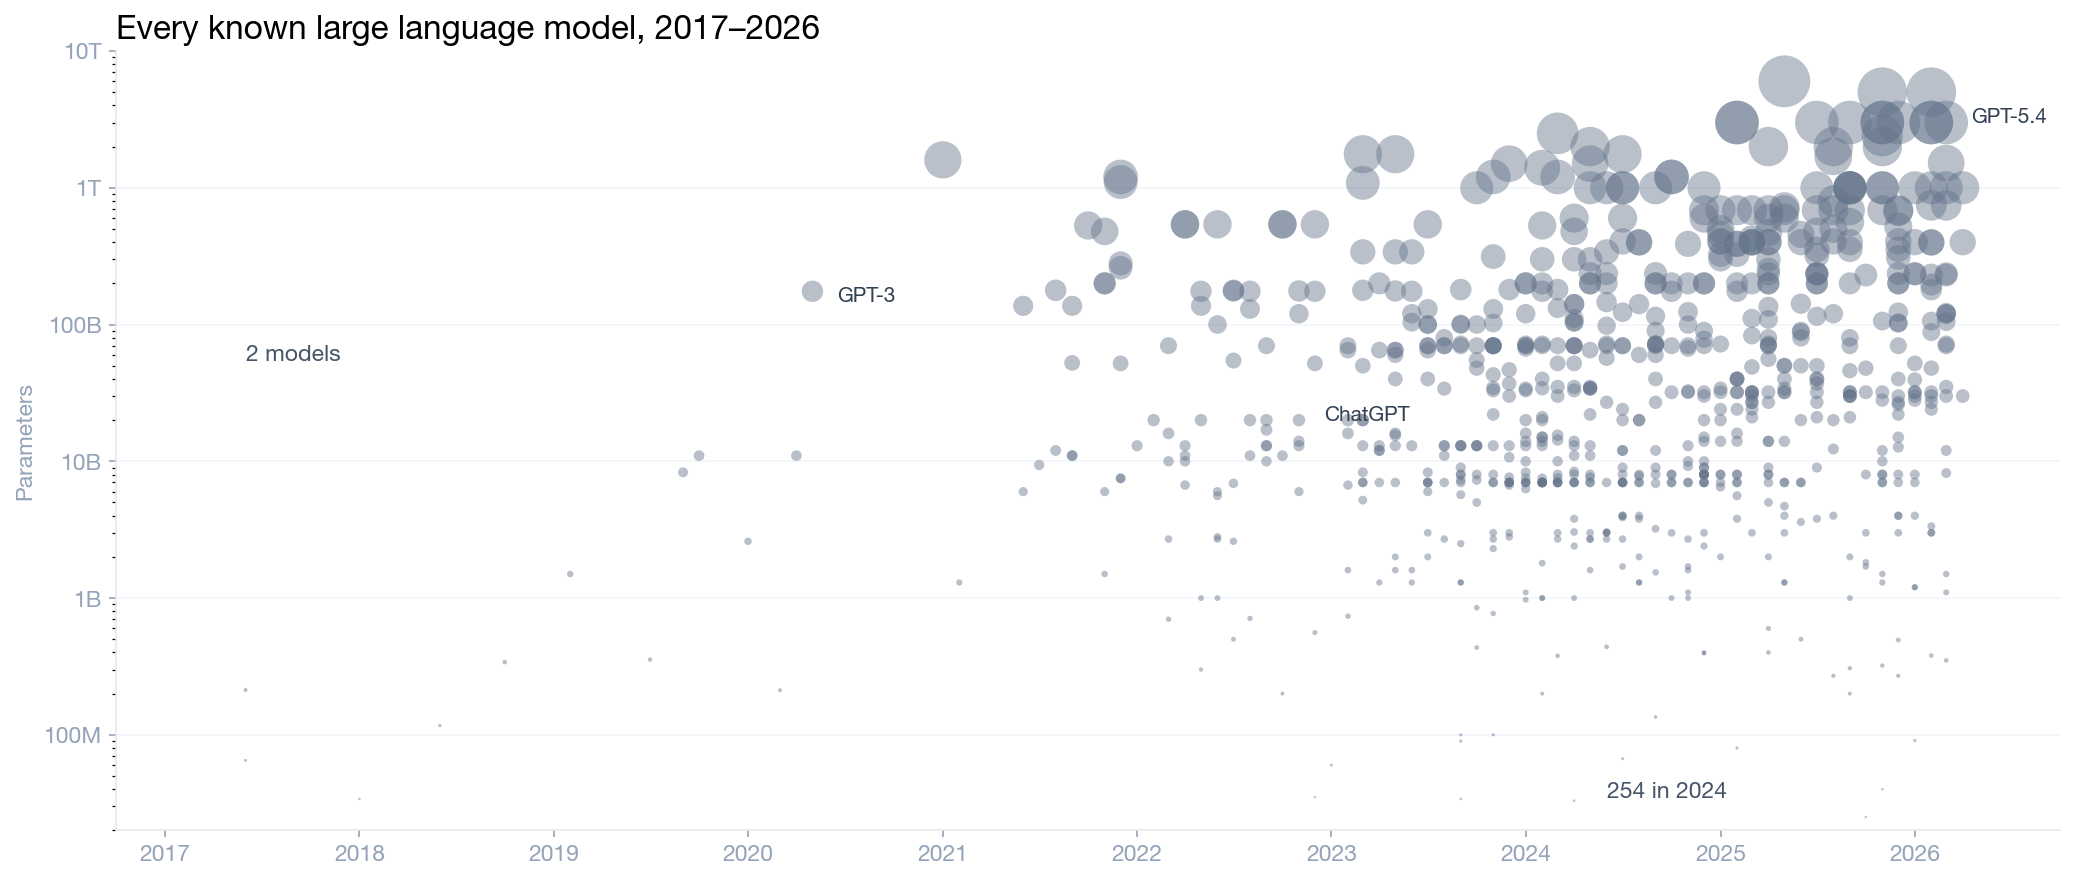

In [104]:
# ── Frame 1: "There has been an explosion of AI models" → SVG ──
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

valid = df[df['params'] > 0].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Much larger bubbles with sqrt scaling — matches the D3 site version
sizes = np.sqrt(valid['params']) * 8
ax.scatter(valid['date'], valid['params'], s=sizes, alpha=0.45,
           color='#64748b', edgecolors='none')

ax.set_yscale('log')
ax.set_ylim(0.02, 10000)
ax.set_xlim(pd.Timestamp('2016-10-01'), pd.Timestamp('2026-10-01'))
ax.set_ylabel('Parameters', fontsize=11, color='#94a3b8')
ax.set_title('Every known large language model, 2017\u20132026',
             fontsize=16, fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}T' if x >= 1000 else f'{x:.0f}B' if x >= 1 else f'{x*1000:.0f}M'))

# Lighter gridlines
for v in [0.1, 1, 10, 100, 1000]:
    ax.axhline(v, color='#f1f5f9', linewidth=0.8, zorder=0)

# Labels for key models
for name, dx, dy in [('GPT-3', 12, -5), ('GPT-5.4', 12, 0), ('ChatGPT', 12, 0)]:
    hits = valid[valid['model'].str.contains(name)]
    if len(hits):
        r = hits.iloc[0]
        ax.annotate(name, (r['date'], r['params']), fontsize=10, fontweight='bold',
                    color='#334155', xytext=(dx, dy), textcoords='offset points')

# Annotations
ax.text(pd.Timestamp('2017-06-01'), 55, '2 models', fontsize=11,
        fontweight='bold', color='#475569')
ax.text(pd.Timestamp('2024-06-01'), 0.035, '254 in 2024', fontsize=11,
        fontweight='bold', color='#475569')

ax.spines['left'].set_color('#e5e7eb')
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(colors='#94a3b8')

plt.tight_layout()
fig.savefig('charts/svg/frame1_overview.svg', format='svg', bbox_inches='tight')
print('Saved → frame1_overview.svg')
plt.show()

---
## 9. Article body charts (SVG for ai2html)

In [105]:
# ── Reload data ──
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
# Fix: SVG backend needs string weight names, not integers
matplotlib.rcParams['font.weight'] = 'normal'

with open('data/models_data.json') as f:
    raw = json.load(f)
df = pd.DataFrame(raw)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

CHINA_KW = [
    'Alibaba', 'Qwen', 'DeepSeek', 'Baidu', 'ERNIE', 'Tencent', 'Hunyuan',
    'Xiaomi', 'MiMo', 'Moonshot', 'Kimi', 'MiniMax', 'Zhipu', 'Z.AI', 'GLM',
    'ByteDance', '01.AI', 'Yi-', 'SenseTime', 'Shanghai AI', 'Inclusion',
    'InclusionAI', 'Nanbeige', 'JD Open', 'StepFun', 'Internlm', 'YuanLab',
    'Baichuan', 'RWKV', 'MOSS', 'vivo', 'Fudan'
]
df['is_chinese'] = df['lab'].apply(lambda x: any(kw in x for kw in CHINA_KW))
print(f'{len(df)} models loaded')

796 models loaded


Saved → article_arms_race.svg


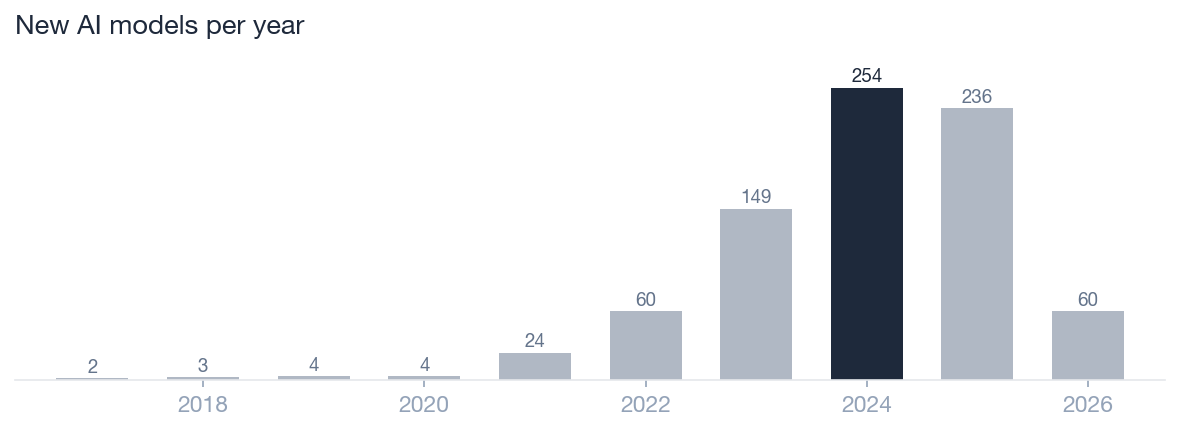

In [106]:
# ── CHART A: The arms race — models per year ──
counts = df.groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 3))

colors = ['#1e293b' if yr == 2024 else '#b0b8c4' for yr in counts.index]
ax.bar(counts.index, counts.values, color=colors, width=0.65)

for yr, v in zip(counts.index, counts.values):
    ax.text(yr, v + 5, str(v), ha='center', fontsize=9,
            color='#1e293b' if yr == 2024 else '#64748b',
            fontweight='bold' if yr == 2024 else 'normal')

ax.set_ylim(0, 290)
ax.set_xlim(2016.3, 2026.7)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(left=False, labelleft=False, colors='#94a3b8')
ax.set_title('New AI models per year', fontsize=13, fontweight='bold', loc='left', color='#1e293b')

plt.tight_layout()
fig.savefig('charts/svg/article_arms_race.svg', format='svg', bbox_inches='tight')
print('Saved → article_arms_race.svg')
plt.show()

Saved → article_sota_rate.svg


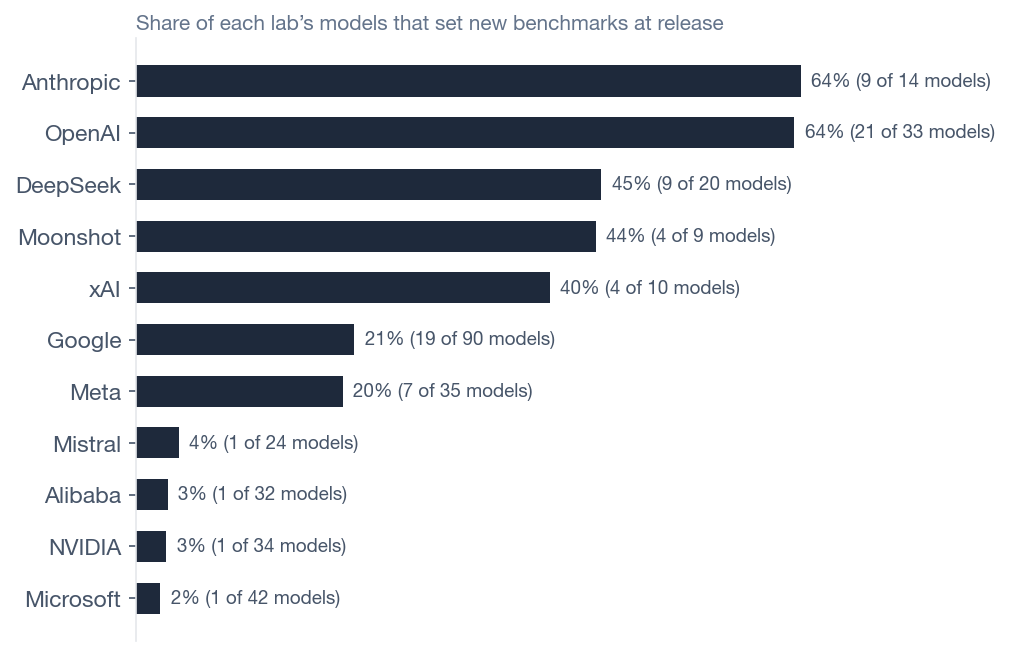

In [114]:
# ── CHART B: Who's most efficient at producing breakthroughs? ──
# Sorted by HIT RATE — the editorial point is efficiency, not volume.
# All bars same colour. "X of Y" labels show both numbers.
# Reader sees: DeepSeek/Moonshot at top (efficient), Microsoft at bottom (specialist).

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

labs = ['OpenAI', 'Anthropic', 'Google', 'DeepSeek', 'Meta', 'xAI', 'Moonshot', 'Alibaba', 'Mistral', 'NVIDIA', 'Microsoft']
sota_data = []
for lab in labs:
    s = df[df['lab_group'] == lab]
    total = len(s)
    sota = int(s['sota'].sum())
    rate = sota / total * 100 if total else 0
    sota_data.append({'lab': lab, 'sota': sota, 'total': total, 'rate': rate})

sdf = pd.DataFrame(sota_data).sort_values('rate')

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(sdf['lab'], sdf['rate'], color='#1e293b', height=0.6)

for i, row in enumerate(sdf.itertuples()):
    label = f'{row.rate:.0f}% ({row.sota} of {row.total} models)'
    ax.text(row.rate + 1, i, label, va='center', fontsize=9, color='#475569')

ax.set_xlim(0, 85)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#e5e7eb')
ax.tick_params(bottom=False, labelbottom=False, colors='#475569')
ax.text(0, len(sdf), 'Share of each lab\u2019s models that set new benchmarks at release', fontsize=10, color='#64748b')

plt.tight_layout()
fig.savefig('charts/svg/article_sota_rate.svg', format='svg', bbox_inches='tight')
print('Saved → article_sota_rate.svg')
plt.show()

Saved → article_openai_trails.svg


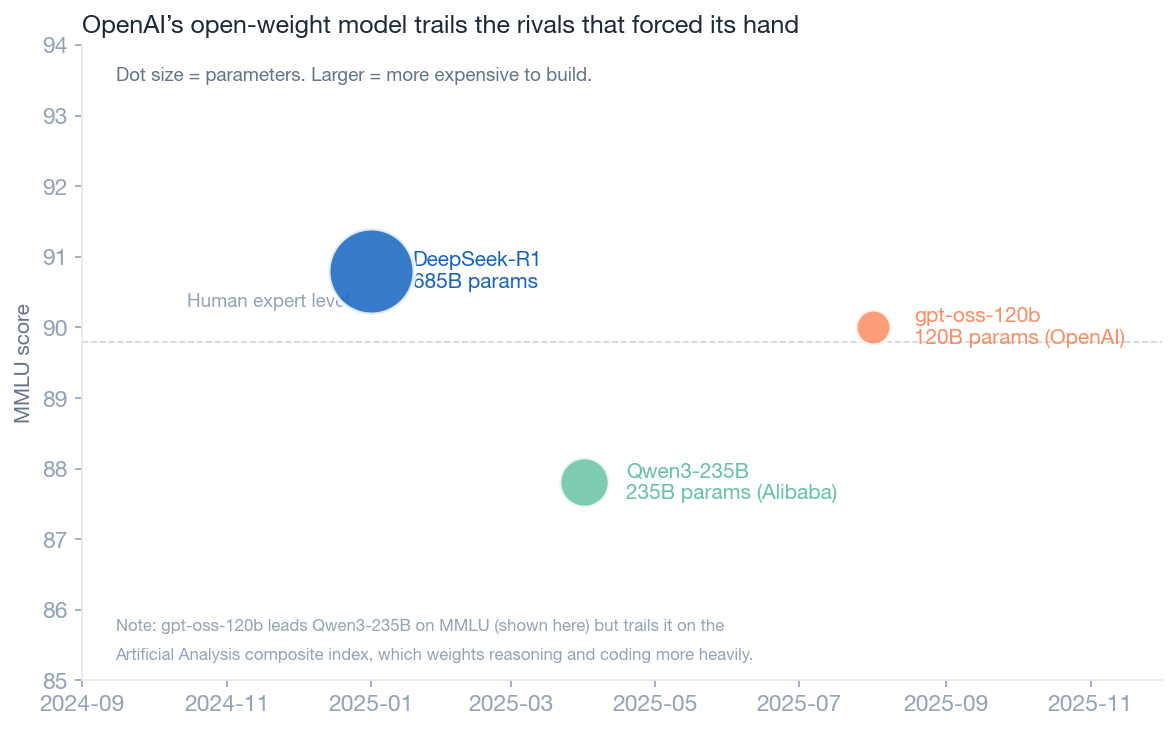

In [ ]:
# ── CHART B2: gpt-oss-120b vs DeepSeek R1 vs Qwen3-235B ──
# Zooming in on the three models. Grey context removed for a clean comparison.

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

with open('data/mmlu_data.json') as f:
    mmlu_data = json.load(f)

mdf = pd.DataFrame(mmlu_data)
mdf['date'] = pd.to_datetime(mdf['date'])

models = [
    {'name': 'Qwen3-235B-A22B', 'color': '#66c2a5', 'label': 'Qwen3-235B\n235B params (Alibaba)'},
    {'name': 'gpt-oss-120b', 'color': '#fc8d62', 'label': 'gpt-oss-120b\n120B params (OpenAI)'},
    {'name': 'DeepSeek-R1', 'color': '#1565c0', 'label': 'DeepSeek-R1\n685B params'},
]

fig, ax = plt.subplots(figsize=(8, 5))

for m in models:
    row = mdf[mdf['model'] == m['name']].iloc[0]
    size = row['params'] * 2.5
    ax.scatter(row['date'], row['mmlu'], s=size, c=m['color'],
               edgecolors='white', linewidths=2, alpha=0.85, zorder=10)
    
    # Place labels to the right of each dot
    ax.annotate(m['label'], (row['date'], row['mmlu']),
                xytext=(20, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=m['color'],
                ha='left', va='center')

# Reference line
ax.axhline(89.8, color='#d1d5db', linewidth=0.8, linestyle='--', zorder=0)
ax.text(pd.Timestamp('2024-10-15'), 90.3, 'Human expert level', fontsize=9, color='#94a3b8')

ax.set_xlim(pd.Timestamp('2024-09-01'), pd.Timestamp('2025-12-01'))
ax.set_ylim(85, 94)
ax.set_ylabel('MMLU score', fontsize=10, color='#64748b')
ax.spines['left'].set_color('#e5e7eb')
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(colors='#94a3b8')

ax.set_title('OpenAI\u2019s open-weight model trails the rivals that forced its hand',
             fontsize=12, fontweight='bold', loc='left', color='#1e293b')
ax.text(pd.Timestamp('2024-09-15'), 93.5,
        'Dot size = parameters. Larger = more expensive to build.',
        fontsize=9, color='#64748b')

# Benchmark nuance note
ax.text(pd.Timestamp('2024-09-15'), 85.7,
        'Note: gpt-oss-120b leads Qwen3-235B on MMLU (shown here) but trails it on the',
        fontsize=8, color='#94a3b8', fontstyle='italic')
ax.text(pd.Timestamp('2024-09-15'), 85.3,
        'Artificial Analysis composite index, which weights reasoning and coding more heavily.',
        fontsize=8, color='#94a3b8', fontstyle='italic')

plt.tight_layout()
fig.savefig('charts/svg/article_openai_trails.svg', format='svg', bbox_inches='tight')
print('Saved \u2192 article_openai_trails.svg')
plt.show()

Saved → article_openai_trails_mobile.svg


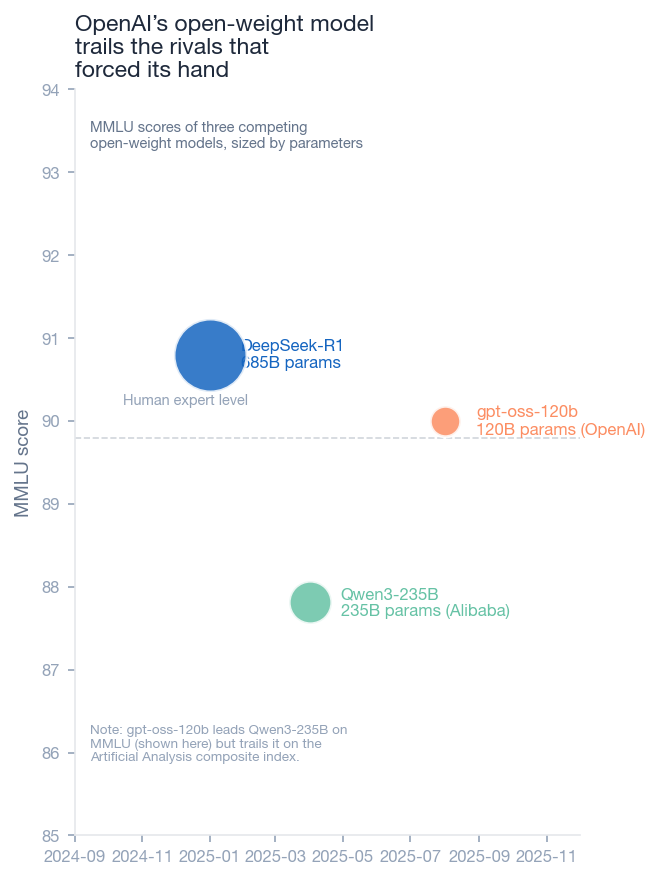

In [109]:
# ── CHART B2 MOBILE ──
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

with open('data/mmlu_data.json') as f:
    mmlu_data = json.load(f)

mdf = pd.DataFrame(mmlu_data)
mdf['date'] = pd.to_datetime(mdf['date'])

models = [
    {'name': 'Qwen3-235B-A22B', 'color': '#66c2a5', 'label': 'Qwen3-235B\n235B params (Alibaba)'},
    {'name': 'gpt-oss-120b', 'color': '#fc8d62', 'label': 'gpt-oss-120b\n120B params (OpenAI)'},
    {'name': 'DeepSeek-R1', 'color': '#1565c0', 'label': 'DeepSeek-R1\n685B params'},
]

fig, ax = plt.subplots(figsize=(4.5, 6))

for m in models:
    row = mdf[mdf['model'] == m['name']].iloc[0]
    size = row['params'] * 1.8
    ax.scatter(row['date'], row['mmlu'], s=size, c=m['color'],
               edgecolors='white', linewidths=1.5, alpha=0.85, zorder=10)
    ax.annotate(m['label'], (row['date'], row['mmlu']),
                xytext=(15, 0), textcoords='offset points',
                fontsize=8, fontweight='bold', color=m['color'],
                ha='left', va='center')

ax.axhline(89.8, color='#d1d5db', linewidth=0.8, linestyle='--', zorder=0)
ax.text(pd.Timestamp('2024-10-15'), 90.2, 'Human expert level', fontsize=7, color='#94a3b8')

ax.set_xlim(pd.Timestamp('2024-09-01'), pd.Timestamp('2025-12-01'))
ax.set_ylim(85, 94)
ax.set_ylabel('MMLU score', fontsize=9, color='#64748b')
ax.spines['left'].set_color('#e5e7eb')
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(colors='#94a3b8', labelsize=8)

ax.set_title('OpenAI\u2019s open-weight model\ntrails the rivals that\nforced its hand',
             fontsize=11, fontweight='bold', loc='left', color='#1e293b')
ax.text(pd.Timestamp('2024-09-15'), 93.3,
        'MMLU scores of three competing\nopen-weight models, sized by parameters',
        fontsize=7, color='#64748b')

ax.text(pd.Timestamp('2024-09-15'), 85.9,
        'Note: gpt-oss-120b leads Qwen3-235B on\nMMLU (shown here) but trails it on the\nArtificial Analysis composite index.',
        fontsize=6.5, color='#94a3b8', fontstyle='italic')

plt.tight_layout()
fig.savefig('charts/svg/article_openai_trails_mobile.svg', format='svg', bbox_inches='tight')
print('Saved \u2192 article_openai_trails_mobile.svg')
plt.show()

Saved → article_china.svg


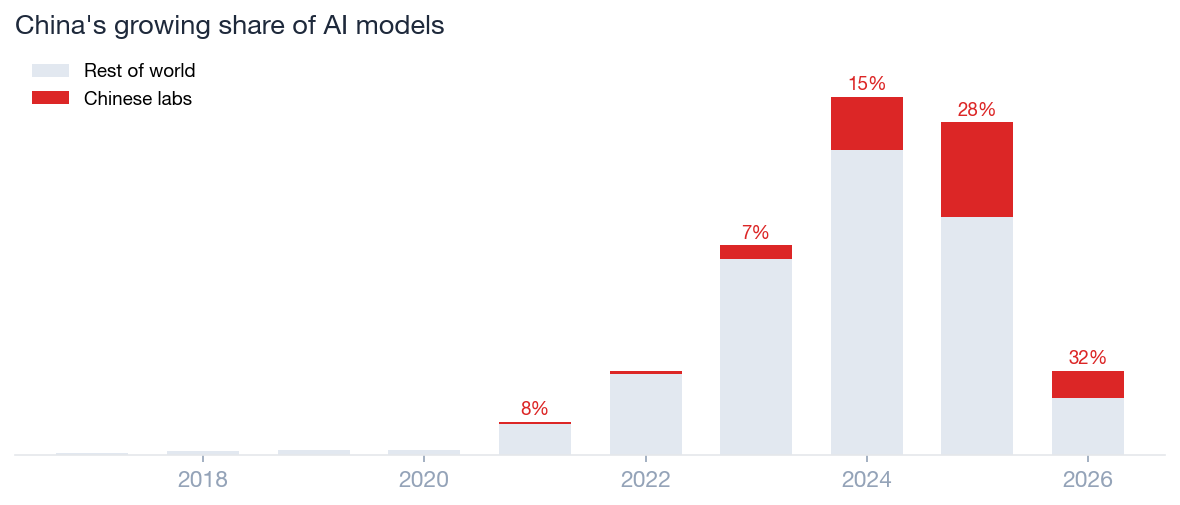

In [110]:
# ── CHART C: China's surge — stacked bar ──
cby = df.groupby('year').agg(total=('model', 'count'), chinese=('is_chinese', 'sum'))
cby['rest'] = cby['total'] - cby['chinese']
cby['pct'] = cby['chinese'] / cby['total'] * 100

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.bar(cby.index, cby['rest'], color='#e2e8f0', width=0.65, label='Rest of world')
ax.bar(cby.index, cby['chinese'], bottom=cby['rest'], color='#dc2626', width=0.65, label='Chinese labs')

for yr, row in cby.iterrows():
    if row['pct'] >= 5:
        ax.text(yr, row['total'] + 5, f'{row.pct:.0f}%', ha='center', fontsize=9,
                color='#dc2626', fontweight='bold')

ax.set_ylim(0, 290)
ax.set_xlim(2016.3, 2026.7)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(left=False, labelleft=False, colors='#94a3b8')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.set_title("China's growing share of AI models", fontsize=13, fontweight='bold', loc='left', color='#1e293b')

plt.tight_layout()
fig.savefig('charts/svg/article_china.svg', format='svg', bbox_inches='tight')
print('Saved → article_china.svg')
plt.show()

Saved → article_reasoning.svg


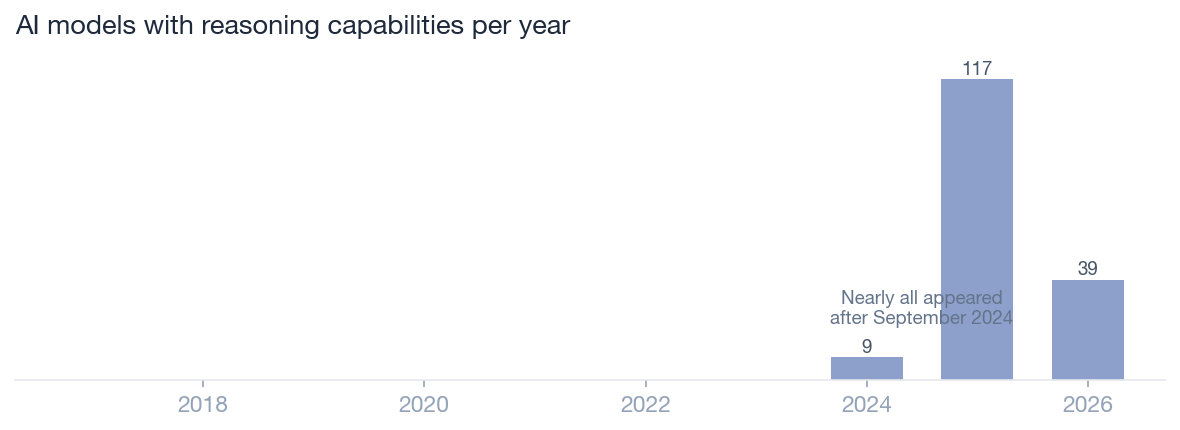


Meta: 0/35 reasoning models


In [111]:
# ── CHART D: Reasoning — bar chart by year + Meta callout ──
rby = df.groupby('year')['reasoning'].sum().astype(int)

fig, ax = plt.subplots(figsize=(8, 3))

bars = ax.bar(rby.index, rby.values, color='#8da0cb', width=0.65)

for yr, v in zip(rby.index, rby.values):
    if v > 0:
        ax.text(yr, v + 2, str(v), ha='center', fontsize=9, color='#475569')

ax.set_ylim(0, 130)
ax.set_xlim(2016.3, 2026.7)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(left=False, labelleft=False, colors='#94a3b8')
ax.set_title('AI models with reasoning capabilities per year', fontsize=13, fontweight='bold', loc='left', color='#1e293b')

# Callout annotation
ax.annotate('Nearly all appeared\nafter September 2024',
            xy=(2024.5, 22), fontsize=9, color='#64748b', fontstyle='italic',
            ha='center')

plt.tight_layout()
fig.savefig('charts/svg/article_reasoning.svg', format='svg', bbox_inches='tight')
print('Saved → article_reasoning.svg')
plt.show()

# Meta stat for the article
meta_r = df[(df['lab_group'] == 'Meta') & df['reasoning']].shape[0]
meta_t = df[df['lab_group'] == 'Meta'].shape[0]
print(f'\nMeta: {meta_r}/{meta_t} reasoning models')

---
## 10. Summary of key findings

| Finding | Data point | Source |
|---------|-----------|--------|
| 796 models total | `len(df)` | LifeArchitect.ai |
| 254 models in 2024 (peak year) | year count | LifeArchitect.ai |
| China: 0% (2020) → 28% (2025) → 30% (2026) | keyword match | LifeArchitect.ai |
| OpenAI SOTA rate: 64% (21/33) | sota field | LifeArchitect.ai |
| DeepSeek SOTA rate: 45% (9/20) | sota field | LifeArchitect.ai |
| Moonshot SOTA rate: 44% (4/9) | sota field | LifeArchitect.ai |
| Meta: 0 reasoning models / 35 | reasoning field | LifeArchitect.ai |
| OpenAI Dense→MoE: 0%→100% in 2022→2023 | arch field | LifeArchitect.ai |
| Meta Dense→MoE: 0%→100% in 2024→2025 | arch field | LifeArchitect.ai |
| 165 reasoning models total | reasoning field | LifeArchitect.ai |
| Chinese reasoning: 5 (2024) → 49 (2025) | keyword + reasoning | LifeArchitect.ai |
| Alibaba closed-source pivot (Apr 2, 2026) | **not in data** | Bloomberg |
| OpenAI open-weight release (Aug 2025) | gpt-oss in data | Fortune, TechCrunch |
| DeepSeek V4 on Huawei chips | **not yet released** | The Information |

---
## 11. Major LLMs ranked by capabilities, sized by parameters

The IIB-style bubble chart used in the scrollytelling intro. X = date, Y = MMLU score, size = parameters. Using the 258 models with published MMLU scores (+ 2 estimated for Alibaba's newest closed models).

Saved → charts/svg/mmlu_bubble_overview.svg (260 models)


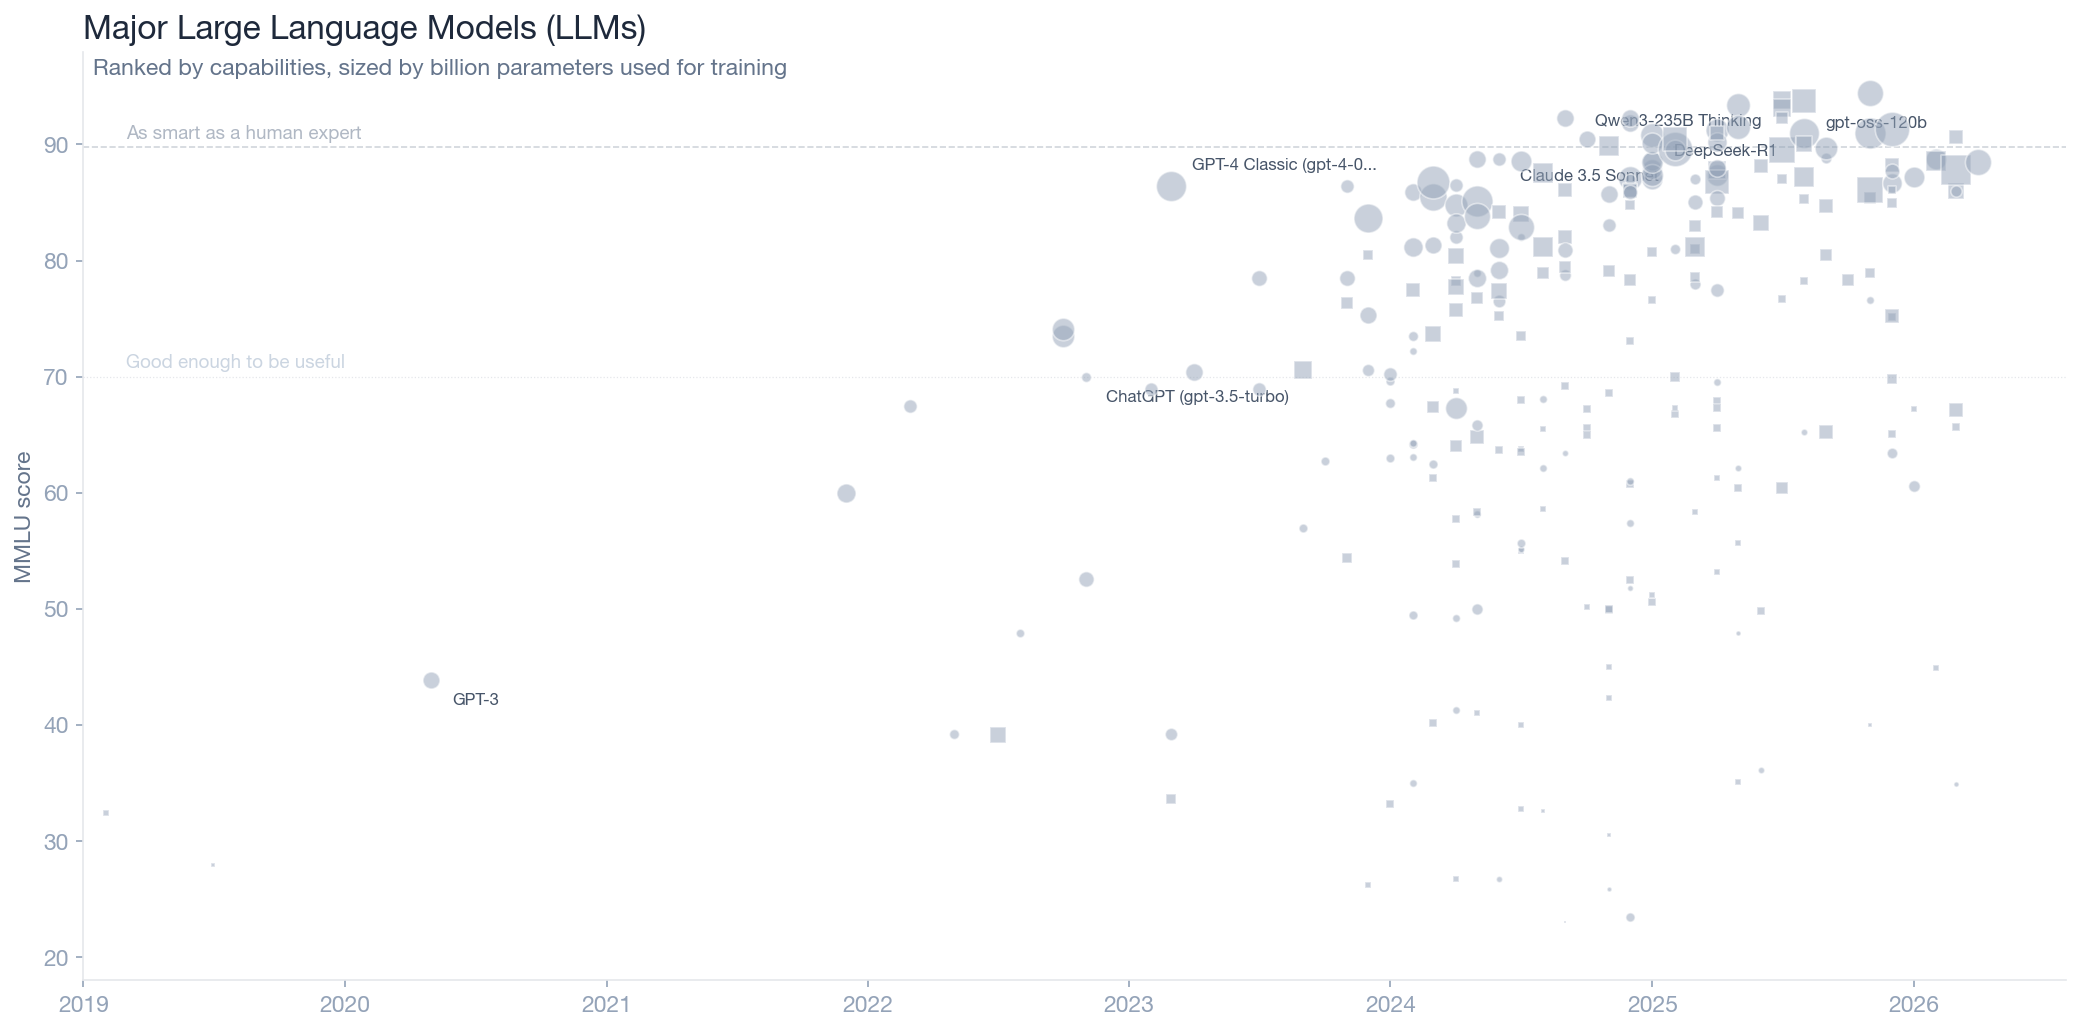

In [ ]:
# ── Major LLMs: MMLU bubble chart → SVG ──
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'

with open('data/mmlu_data.json') as f:
    mmlu = json.load(f)

mdf = pd.DataFrame(mmlu)
mdf['date'] = pd.to_datetime(mdf['date'])

fig, ax = plt.subplots(figsize=(14, 7))

# Size by params, colour all grey, open-weight as squares
for _, row in mdf.iterrows():
    size = np.sqrt(row['params']) * 5
    marker = 's' if row['ow'] else 'o'
    rotation = 45 if row['ow'] else 0
    ax.scatter(row['date'], row['mmlu'], s=size, c='#94a3b8',
               edgecolors='white', linewidths=0.8, alpha=0.5, zorder=5,
               marker=marker)

# Reference lines
ax.axhline(89.8, color='#d1d5db', linewidth=0.8, linestyle='--', zorder=0)
ax.text(pd.Timestamp('2019-03-01'), 90.5, 'As smart as a human expert', fontsize=9, color='#b0b8c4')
ax.axhline(70, color='#e5e7eb', linewidth=0.6, linestyle=':', zorder=0)
ax.text(pd.Timestamp('2019-03-01'), 70.8, 'Good enough to be useful', fontsize=9, color='#cbd5e1')

# Label key models
key_models = [
    ('GPT-3', 10, -12), ('GPT-4 Classic', 10, 8), ('ChatGPT', 10, -12),
    ('GPT-5.4', -10, 8), ('DeepSeek-R1', 10, -10), ('gpt-oss-120b', 10, 8),
    ('Qwen3-235B-A22B-Thinking', -10, -12), ('Claude 3.5 Sonnet', 10, -10),
]
for name, dx, dy in key_models:
    hits = mdf[mdf['model'].str.contains(name)]
    if len(hits):
        r = hits.iloc[0]
        short = r['model'].replace('-A22B-Thinking-2507', ' Thinking')
        if len(short) > 25: short = short[:22] + '...'
        ax.annotate(short, (r['date'], r['mmlu']), fontsize=8, color='#475569',
                    fontweight='bold', xytext=(dx, dy), textcoords='offset points',
                    ha='left' if dx > 0 else 'right')

ax.set_xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2026-08-01'))
ax.set_ylim(18, 98)
ax.set_ylabel('MMLU score', fontsize=11, color='#64748b')
ax.spines['left'].set_color('#e5e7eb')
ax.spines['bottom'].set_color('#e5e7eb')
ax.tick_params(colors='#94a3b8')

ax.set_title('Major Large Language Models (LLMs)', fontsize=16, fontweight='bold', loc='left', color='#1e293b')
ax.text(pd.Timestamp('2019-01-15'), 96,
        'Ranked by capabilities, sized by billion parameters used for training',
        fontsize=11, color='#64748b')

plt.tight_layout()
fig.savefig('charts/svg/mmlu_bubble_overview.svg', format='svg', bbox_inches='tight')
print(f'Saved → charts/svg/mmlu_bubble_overview.svg ({len(mdf)} models)')
plt.show()